# Nutri-Score voorspellen op basis van voedingswaarden

**Machine learning op de Delhaize-productdatabase.**

We laden producten met hun voedingsdetails uit SQL Server, parsen de `NutritionPer100` JSON,
bouwen een featureset van 8 voedingsstoffen en trainen modellen die de Nutri-Score (A-E) voorspellen.

> Bij elke stap tonen we `df.shape` / `df.head()` / `df.dtypes` en geven we 1 regel uitleg. Elke plot heeft titel + labels.

## Deel 1 - Data inladen en eerste verkenning

### Opdracht 1.1 - Setup
Importeren van pandas, numpy, matplotlib, seaborn en de eigen `get_engine` / `getData` uit `database.py`.

In [47]:
from pathlib import Path
import sys

# database.py staat in de scraper-map (zelfde import-patroon als analyser.ipynb)
ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scraper.database import get_engine, getData

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

engine = get_engine()
print("Engine klaar:", engine)

Engine klaar: Engine(mssql+pyodbc:///?odbc_connect=DRIVER%3D%7BODBC+Driver+17+for+SQL+Server%7D%3BSERVER%3Dlocalhost%3BDATABASE%3DDelhaize%3BTrusted_Connection%3Dyes%3BTrustServerCertificate%3Dyes%3B)


### Opdracht 1.2 - Data laden
We joinen `Products` met `ProductDetails` op `ProductId`. De `NutriScore` nemen we uit
`ProductDetails` (`d.NutriScore`) omdat die betrouwbaarder is.

In [48]:
query = """
SELECT
    p.ProductId,
    p.Name,
    p.Brand,
    p.CategoryCode,
    d.NutriScore,          -- uit ProductDetails (betrouwbaarder)
    d.NutritionPer100,
    d.Ingredients
FROM Products p
JOIN ProductDetails d ON p.ProductId = d.ProductId
"""

df = getData(engine, query=query)
print("Producten met details geladen uit SQL Server")
df.shape

Producten met details geladen uit SQL Server


(13512, 7)

**Vorm:** aantal rijen (producten) x kolommen. Hieronder de eerste 5 rijen.

In [49]:
df.head()

,ProductId,Name,Brand,CategoryCode,NutriScore,NutritionPer100,Ingredients
0,F1981081800104400000,Karneboter,Delhaize,v2DAI,E,"{""columns"": [""Niet Bereid 100 g"", ""Niet Bereid...","Room (MELK), starterculturen (bevat: MELK)"
1,F1981081800113700000,Yoghurt | Natuur | Melkspecialiteit,Danone,v2DAI,C,"{""columns"": [""Niet Bereid 100 g"", ""Niet Bereid...",", volle MELK, room (MELK), MELKeiwitten, MELKf..."
2,F1981081800114000000,Verse Kaas | Petit Suisse | Mager | 20% v.g.,Danone,v2DAI,A,"{""columns"": [""Niet Bereid 100 g"", ""Niet Bereid...",", verse kaas met (20%) V.G./D.S. (waarvan 100%..."
3,F1981081800115600000,Kwark | Aardbei | Opgeklopt,Danio,v2DAI,C,"{""columns"": [""Niet Bereid 100 g"", ""Niet Bereid...",", magere MELK, magere verse kaas (29,7%) (MELK..."
4,F1981081800132200000,Flan | Karamelsaus,La Laitière,v2DAI,C,"{""columns"": [""Niet Bereid 100 g""], ""rows"": [{""...","Volle MELK (76,0%), suiker, karamel (6,0%) (gl..."


**Datatypes:** NutriScore is object (letter A-E); NutritionPer100 en Ingredients zijn tekst (JSON-strings).

In [50]:
df.dtypes

ProductId          str
Name               str
Brand              str
CategoryCode       str
NutriScore         str
NutritionPer100    str
Ingredients        str
dtype: object

### Opdracht 1.3 - Eerste statistieken
We tellen hoeveel producten een Nutri-Score, een `NutritionPer100`, beide, of geen Nutri-Score hebben.
De groep met *beide* is onze trainingsset.

In [51]:
heeft_nutriscore = df["NutriScore"].notna().sum()
geen_nutriscore  = df["NutriScore"].isna().sum()
heeft_nutrition  = df["NutritionPer100"].notna().sum()
heeft_beide      = (df["NutriScore"].notna() & df["NutritionPer100"].notna()).sum()

print(f"Producten MET NutriScore          : {heeft_nutriscore}")
print(f"Producten ZONDER NutriScore       : {geen_nutriscore}")
print(f"Producten met NutritionPer100     : {heeft_nutrition}")
print(f"Producten met BEIDE (trainingsset): {heeft_beide}")

Producten MET NutriScore          : 5172
Producten ZONDER NutriScore       : 8340
Producten met NutritionPer100     : 8488
Producten met BEIDE (trainingsset): 5052


### Opdracht 1.4 - Distributie van Nutri-Scores

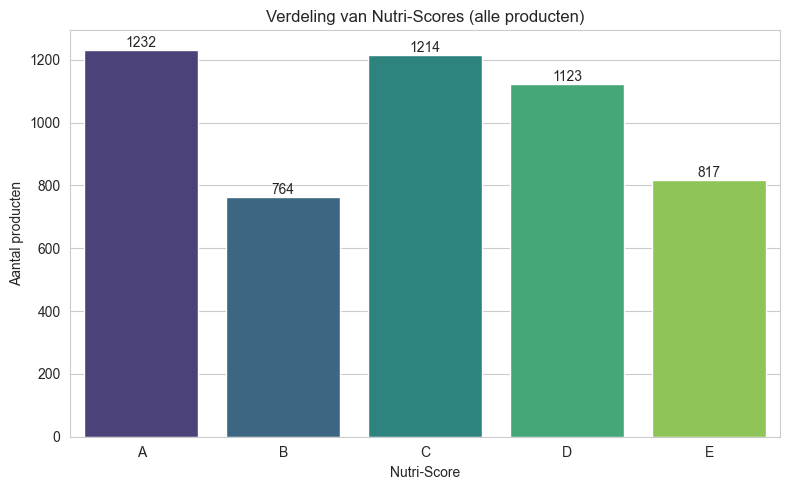

NutriScore
A    1232
B     764
C    1214
D    1123
E     817
Name: count, dtype: int64

Baseline accuracy (altijd 'A' voorspellen): 0.239


In [52]:
order = ["A", "B", "C", "D", "E"]
counts = df["NutriScore"].value_counts().reindex(order)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="viridis", legend=False)
for i, v in enumerate(counts.values):
    ax.text(i, v, str(int(v)), ha="center", va="bottom")
plt.title("Verdeling van Nutri-Scores (alle producten)")
plt.xlabel("Nutri-Score")
plt.ylabel("Aantal producten")
plt.tight_layout()
plt.show()

print(counts)
baseline_acc = counts.max() / counts.sum()
print(f"\nBaseline accuracy (altijd '{counts.idxmax()}' voorspellen): {baseline_acc:.3f}")

**Antwoord (1.4):**
- **Meest voorkomend:** de hoogste balk hierboven (`counts.idxmax()`).
- **Zeldzaamst:** de laagste balk (`counts.idxmin()`).
- **Baseline accuracy:** altijd de meest voorkomende klasse voorspellen geeft de geprinte `baseline_acc`. Elk echt model moet dit verslaan.

## Deel 2 - Data parsen en opschonen

De `NutritionPer100` kolom bevat JSON zoals:
```json
{"columns": [...], "rows": [{"name": "Energie", "values": ["1496 KJ", "299 KJ (4%)"]}, ...], "groups": [...]}
```

### Opdracht 2.1 - JSON parsen
`parse_nutrition(json_string)` geeft `{nutrient_naam: ruwe_waarde_per_100g}` terug.

> Dit is **dezelfde JSON-aanpak als in mijn `analyser.ipynb`**: `json.loads`, daarna itereren over
> `data["rows"]` en telkens de **eerste** waarde (`values[0]`, kolom 1 = per 100g/ml) nemen. Het enige
> verschil is dat ik de ruwe waarde mét eenheid teruggeef, zodat het strippen netjes in `parse_value` (2.2) zit.

In [53]:
import json

def parse_nutrition(json_string):
    """Geeft {nutrient_naam: ruwe_waarde_per_100g} terug, bv. {'Energie': '419 KJ', ...}.
    Zelfde aanpak als getNutritionGroups in analyser.ipynb: json.loads + itereren over
    data['rows'], telkens values[0] (kolom 1 = per 100g/ml)."""
    if pd.isna(json_string):
        return None
    data = json.loads(json_string)
    return {row["name"]: row["values"][0] for row in data["rows"]}

In [54]:
# Test op 3 willekeurige rijen met ingevulde NutritionPer100
sample = df[df["NutritionPer100"].notna()].sample(3, random_state=1)
for pid, js in zip(sample["ProductId"], sample["NutritionPer100"]):
    print(pid)
    print(parse_nutrition(js))
    print()

S2022120900664860000
{'Energie': '1435 KJ', 'Kilocalorieën': '343 KCAL', 'Vetten waarvan': '19 g', 'Verzadigde vetten': '12 g', 'Koolhydraten waarvan': '39 g', 'Suikers': '30 g', 'Eiwitten': '4.7 g', 'Zout': '0.32 g'}

S1994102800063870000
{'Energie': '2287 KJ', 'Kilocalorieën': '547 KCAL', 'Vetten waarvan': '37.3 g', 'Verzadigde vetten': '19.4 g', 'Koolhydraten waarvan': '41.1 g', 'Suikers': '38.2 g', 'Eiwitten': '5.7 g', 'Zout': '0.1 g'}

S2023041400695700000
{'Energie': '0', 'Kilocalorieën': '0', 'Vetten waarvan': '0', 'Verzadigde vetten': '0', 'Koolhydraten waarvan': '0', 'Suikers': '0', 'Eiwitten': '0', 'Zout': '0'}



### Opdracht 2.2 - Eenheden strippen
`parse_value(s)` zet `"2.4 g"`, `"299 KJ (4%)"`, `"< 0.5 g"` om naar float.
Bij `"< 0.5 g"` -> `0.5`. Onparsbaar -> `None`. (Belgische komma's worden ook afgehandeld.)

In [55]:
import re

def parse_value(s):
    """Zet een waarde-string om naar float. '< 0.5 g' -> 0.5, onparsbaar -> None."""
    if s is None or (isinstance(s, float) and pd.isna(s)):
        return None
    s = str(s).strip()
    if s == "":
        return None
    s = s.replace(",", ".")                 # Belgische decimalen
    s = s.replace("<", "").replace(">", "")
    m = re.search(r"-?\d+(\.\d+)?", s)       # eerste getal
    if not m:
        return None
    return float(m.group())

In [56]:
for test in ["2.4 g", "419 KJ", "< 0.5 g", "spoor", ""]:
    print(f"{test!r:12} -> {parse_value(test)}")

'2.4 g'      -> 2.4
'419 KJ'     -> 419.0
'< 0.5 g'    -> 0.5
'spoor'      -> None
''           -> None


### Opdracht 2.3 - Featureset bouwen
We mappen de JSON-namen naar 8 nette featurekolommen, met `.get(naam, None)` als default
(niet elk product heeft elke nutrient).

In [57]:
# JSON-naam  ->  featurekolom
NAME_MAP = {
    "Energie_KJ":          "Energie",
    "Vetten_g":            "Vetten waarvan",
    "Verzadigde_vetten_g": "Verzadigde vetten",
    "Koolhydraten_g":      "Koolhydraten waarvan",
    "Suikers_g":           "Suikers",
    "Vezels_g":            "Vezels",
    "Eiwit_g":             "Eiwitten",
    "Zout_g":              "Zout",
}
FEATURES = list(NAME_MAP.keys())

records = []
for _, row in df.iterrows():
    nut = parse_nutrition(row["NutritionPer100"])   # dict of None
    rec = {"ProductId": row["ProductId"]}
    for col, json_name in NAME_MAP.items():
        raw = nut.get(json_name) if nut else None   # .get met default None
        rec[col] = parse_value(raw)
    rec["NutriScore"] = row["NutriScore"]
    records.append(rec)

features_df = pd.DataFrame(records)
print("features_df gebouwd: 1 rij per product, 8 voedingswaarden + NutriScore")
features_df.shape

features_df gebouwd: 1 rij per product, 8 voedingswaarden + NutriScore


(13512, 10)

In [58]:
features_df.head()

,ProductId,Energie_KJ,Vetten_g,Verzadigde_vetten_g,Koolhydraten_g,Suikers_g,Vezels_g,Eiwit_g,Zout_g,NutriScore
0,F1981081800104400000,3051.0,82.0,50.0,0.5,0.5,0.5,0.5,0.01,E
1,F1981081800113700000,489.0,10.0,7.0,3.9,3.9,NaN,3.1,0.11,C
2,F1981081800114000000,364.0,3.9,2.7,3.8,3.8,NaN,9.1,0.08,A
3,F1981081800115600000,500.0,4.1,2.7,15.7,14.7,NaN,4.7,0.11,C
4,F1981081800132200000,552.0,3.0,2.0,23.5,19.8,0.1,2.4,0.11,C


**Missing values per kolom:** producten zonder die nutrient (of zonder NutritionPer100) zijn NaN.

In [59]:
features_df.isna().sum()

ProductId                 0
Energie_KJ             5043
Vetten_g               5243
Verzadigde_vetten_g    5251
Koolhydraten_g         5223
Suikers_g              5261
Vezels_g               7978
Eiwit_g                5237
Zout_g                 5233
NutriScore             8340
dtype: int64

### Opdracht 2.4 - Missing data behandelen
- `df_train`: rijen met zowel NutriScore als alle 8 voedingswaarden (dropna).
- `df_predict`: producten zonder NutriScore, maar wel met alle 8 voedingswaarden.

In [60]:
df_train   = features_df.dropna(subset=FEATURES + ["NutriScore"]).copy()
df_predict = features_df[features_df["NutriScore"].isna()].dropna(subset=FEATURES).copy()

print("df_train.shape  :", df_train.shape)
print("df_predict.shape:", df_predict.shape)

df_train.shape  : (4152, 10)
df_predict.shape: (1362, 10)


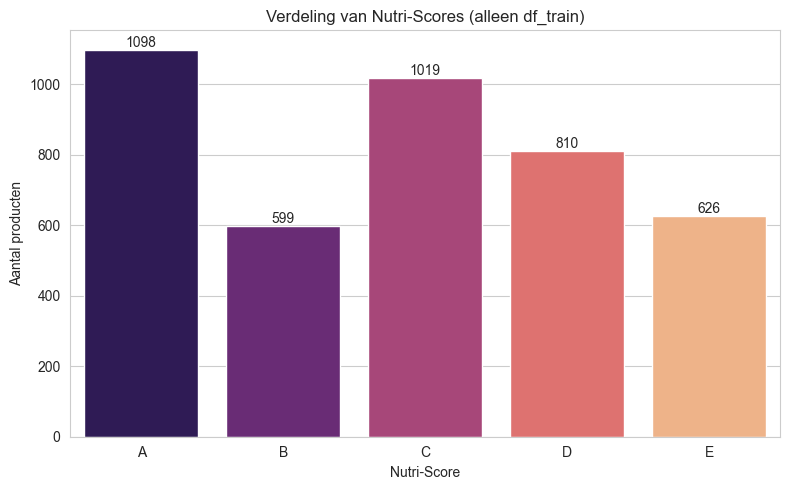

NutriScore
A    1098
B     599
C    1019
D     810
E     626
Name: count, dtype: int64


In [61]:
counts_train = df_train["NutriScore"].value_counts().reindex(order)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=counts_train.index, y=counts_train.values, hue=counts_train.index, palette="magma", legend=False)
for i, v in enumerate(counts_train.values):
    ax.text(i, v, str(int(v)), ha="center", va="bottom")
plt.title("Verdeling van Nutri-Scores (alleen df_train)")
plt.xlabel("Nutri-Score")
plt.ylabel("Aantal producten")
plt.tight_layout()
plt.show()
print(counts_train)

**Is de verdeling evenwichtig? (2.4)**
De klassen zijn **niet gelijk verdeeld** (klasse-onbalans): sommige Nutri-Scores komen veel vaker voor dan
andere. Dat is een aandachtspunt: het model kan de grote klassen bevoordelen en **accuracy alleen kan
misleidend zijn**. Daarom kijken we later ook naar de confusion matrix en per-klasse precision/recall, en
gebruiken we `stratify` bij de split.

## Deel 3 - Exploratieve analyse

### Opdracht 3.1 - Boxplots per voedingsstof
Een grid van 8 boxplots (2 x 4), per voedingsstof de verdeling per Nutri-Score klasse.

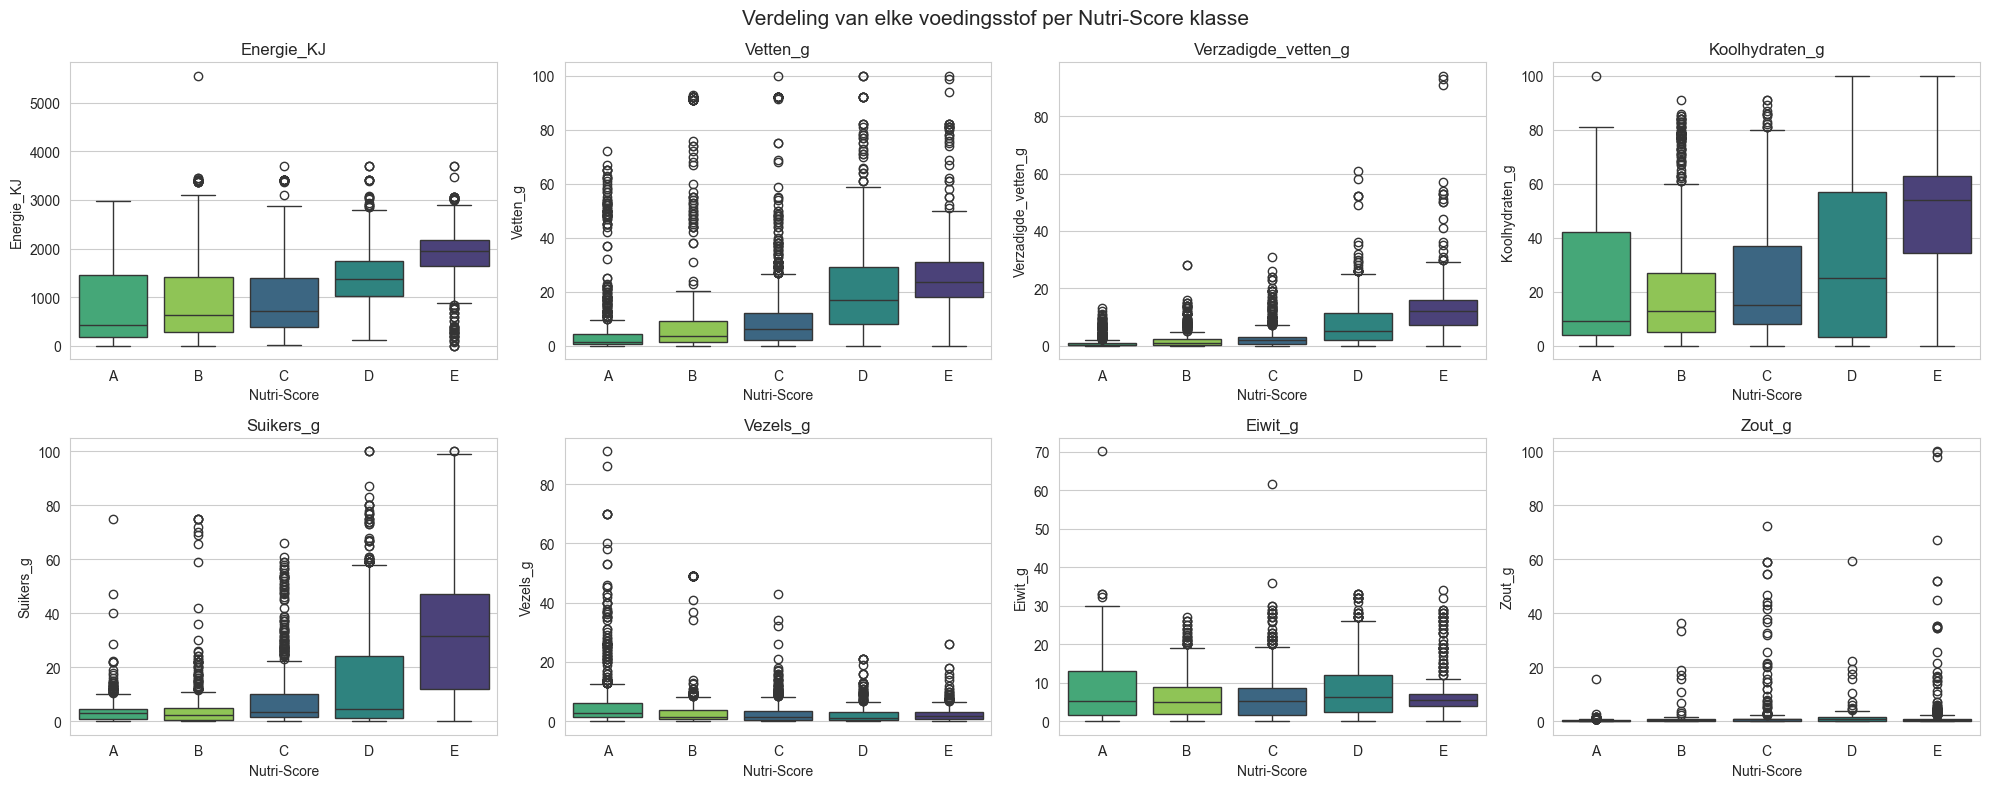

In [62]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.ravel()

for i, feat in enumerate(FEATURES):
    sns.boxplot(data=df_train, x="NutriScore", y=feat, order=order,
                hue="NutriScore", palette="viridis", legend=False, ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel("Nutri-Score")
    axes[i].set_ylabel(feat)

fig.suptitle("Verdeling van elke voedingsstof per Nutri-Score klasse", fontsize=15)
fig.tight_layout()
plt.show()

**Antwoord (3.1):**
- **Duidelijke trend A -> E:** bij energie, verzadigde vetten, vetten en suikers stijgt de mediaan
  doorgaans naarmate de Nutri-Score slechter wordt (A is gezonder, E ongezonder).
- **Geen duidelijk verband:** vezels en eiwit tonen veel overlap tussen de klassen; zout is grillig
  (sterk afhankelijk van het producttype).
- **Verwachte top 3 features:** **Energie_KJ, Verzadigde_vetten_g en Suikers_g** - dit zijn ook de
  pijlers van de echte Nutri-Score-formule.
> Bevestig na het trainen via de feature importance (opdracht 5.3).

### Opdracht 3.2 - Correlatie tussen features
Heatmap van de correlatiematrix van de 8 voedingsstoffen.

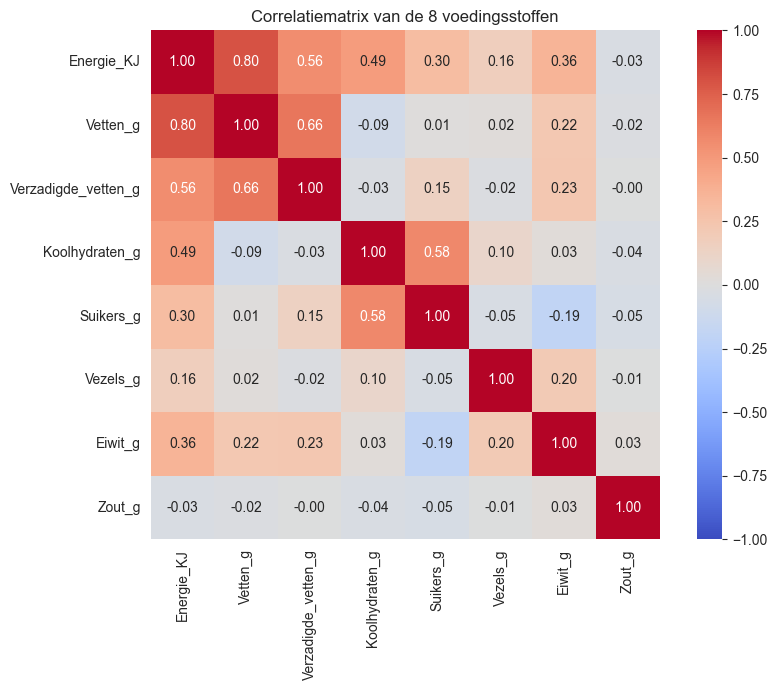

In [63]:
corr = df_train[FEATURES].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlatiematrix van de 8 voedingsstoffen")
plt.tight_layout()
plt.show()

**Antwoord (3.2):**
- **Sterkst gecorreleerd:** doorgaans **Energie_KJ en Vetten_g** (en ook Energie met verzadigde vetten),
  wat logisch is: vetten leveren ~2x zoveel energie per gram als koolhydraten of eiwit, dus meer vet -> meer kJ.
- **Multicollineariteit (> 0.9):** als energie en vetten boven 0.9 uitkomen, dragen ze grotendeels
  dezelfde informatie. Voor een lineair model (Logistic Regression) maakt dit de coefficienten instabiel
  en moeilijk te interpreteren; tree-based modellen (Random Forest, XGBoost) hebben er veel minder last van.

## Deel 4 - Modellen trainen

### Opdracht 4.1 - Train/test split
80/20 met `stratify=y` en `random_state=42`.

In [64]:
from sklearn.model_selection import train_test_split

X = df_train[FEATURES]
y = df_train["NutriScore"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("X_train.shape:", X_train.shape, " X_test.shape:", X_test.shape)
print("\ny_train verdeling:")
print(y_train.value_counts(normalize=True).reindex(order).round(3))
print("\ny_test verdeling:")
print(y_test.value_counts(normalize=True).reindex(order).round(3))

X_train.shape: (3321, 8)  X_test.shape: (831, 8)

y_train verdeling:
NutriScore
A    0.264
B    0.144
C    0.245
D    0.195
E    0.151
Name: proportion, dtype: float64

y_test verdeling:
NutriScore
A    0.265
B    0.144
C    0.245
D    0.195
E    0.150
Name: proportion, dtype: float64


De verdelingen in train en test zijn nagenoeg gelijk - dat is precies wat `stratify=y` garandeert.

### Opdracht 4.2 - Baseline model
`DummyClassifier(strategy="most_frequent")` voorspelt altijd de grootste klasse. Dit is de ondergrens.

In [65]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
acc_dummy = accuracy_score(y_test, dummy.predict(X_test))
print(f"Baseline (dummy) test accuracy: {acc_dummy:.3f}")

Baseline (dummy) test accuracy: 0.265


### Opdracht 4.3 - Logistic Regression
Eerst schalen met `StandardScaler` (nodig voor LogisticRegression), dan trainen.

In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_sc, y_train)

acc_lr_train = accuracy_score(y_train, logreg.predict(X_train_sc))
acc_lr_test  = accuracy_score(y_test,  logreg.predict(X_test_sc))
print(f"Logistic Regression - train accuracy: {acc_lr_train:.3f}")
print(f"Logistic Regression - test  accuracy: {acc_lr_test:.3f}")
print(f"Verschil (train - test): {acc_lr_train - acc_lr_test:.3f}")

Logistic Regression - train accuracy: 0.598
Logistic Regression - test  accuracy: 0.596
Verschil (train - test): 0.002


**Overfitting? (4.3)** Het verschil tussen train- en test-accuracy is klein, dus Logistic Regression
**overfit nauwelijks**. Een lineair model is relatief simpel en generaliseert hier goed - de keerzijde is
dat het de niet-lineaire grenzen tussen de klassen mogelijk niet volledig vat (lagere absolute accuracy).

### Opdracht 4.4 - Random Forest
`RandomForestClassifier(n_estimators=200, random_state=42)`. Schalen is hier niet nodig.

In [67]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

acc_rf_train = accuracy_score(y_train, rf.predict(X_train))
acc_rf_test  = accuracy_score(y_test,  rf.predict(X_test))
print(f"Random Forest - train accuracy: {acc_rf_train:.3f}")
print(f"Random Forest - test  accuracy: {acc_rf_test:.3f}")

Random Forest - train accuracy: 0.998
Random Forest - test  accuracy: 0.776


**Welk model wint nu? (4.4)** De Random Forest haalt een **hogere test-accuracy** dan Logistic
Regression. Reden: de relatie tussen voedingswaarden en Nutri-Score is niet puur lineair (drempelwaarden,
interacties tussen suiker/vet/energie), en een ensemble van beslisbomen vangt dat beter. De hoge
train-accuracy (vaak ~1.0) toont wel dat de bomen het trainingsdeel quasi uit het hoofd leren; het verschil
met de test-accuracy is de mate van overfitting.

### Opdracht 4.5 - Vergelijkingstabel

In [68]:
results = pd.DataFrame([
    {"Model": "Baseline (dummy)",   "Train accuracy": np.nan,        "Test accuracy": acc_dummy},
    {"Model": "Logistic Regression","Train accuracy": acc_lr_train,  "Test accuracy": acc_lr_test},
    {"Model": "Random Forest",      "Train accuracy": acc_rf_train,  "Test accuracy": acc_rf_test},
]).set_index("Model").round(3)
results

,Train accuracy,Test accuracy
Model,,
Baseline (dummy),NaN,0.265
Logistic Regression,0.598,0.596
Random Forest,0.998,0.776


### Opdracht 4.6 - Bonus: XGBoost
XGBoost werkt op numerieke labels, dus we encoderen A-E met `LabelEncoder` (A=0 ... E=4).

In [69]:
try:
    from xgboost import XGBClassifier
    from sklearn.preprocessing import LabelEncoder

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)   # A->0 ... E->4
    y_test_enc  = le.transform(y_test)

    xgb = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                        random_state=42, eval_metric="mlogloss")
    xgb.fit(X_train, y_train_enc)

    acc_xgb_train = accuracy_score(y_train_enc, xgb.predict(X_train))
    acc_xgb_test  = accuracy_score(y_test_enc,  xgb.predict(X_test))
    print(f"XGBoost - train accuracy: {acc_xgb_train:.3f}")
    print(f"XGBoost - test  accuracy: {acc_xgb_test:.3f}")

    results.loc["XGBoost"] = [round(acc_xgb_train, 3), round(acc_xgb_test, 3)]
    HAS_XGB = True
except ImportError:
    print("xgboost niet geinstalleerd. Installeer met: pip install xgboost")
    HAS_XGB = False

XGBoost - train accuracy: 0.992
XGBoost - test  accuracy: 0.763


In [70]:
results

,Train accuracy,Test accuracy
Model,,
Baseline (dummy),NaN,0.265
Logistic Regression,0.598,0.596
Random Forest,0.998,0.776
XGBoost,0.992,0.763


## Deel 5 - Modelevaluatie en interpretatie

We gebruiken vanaf hier het **Random Forest** model (best presterende boom-model, en `feature_importances_`
is beschikbaar voor opdracht 5.3).

In [71]:
best_model = rf
y_pred = best_model.predict(X_test)

### Opdracht 5.1 - Confusion matrix

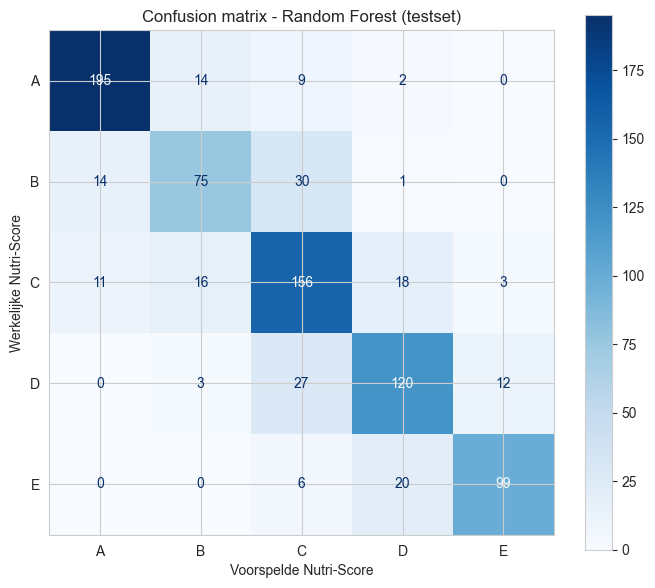

In [72]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=order, cmap="Blues", ax=ax
)
ax.set_title("Confusion matrix - Random Forest (testset)")
ax.set_xlabel("Voorspelde Nutri-Score")
ax.set_ylabel("Werkelijke Nutri-Score")
plt.tight_layout()
plt.show()

**Antwoord (5.1):**
- **Best voorspelde klasse:** de klasse met de hoogste waarde op de diagonaal (meestal de grootste klasse,
  bv. C of D - lees af van de matrix).
- **Vaakst verward:** de twee klassen met de grootste off-diagonale cellen - typisch **buurklassen** (bv. B<->C of C<->D).
- **Naast of ver weg?** De fouten zitten vrijwel allemaal **naast** de juiste klasse (A<->B, B<->C), zelden
  ver weg (A<->E). Dat is goed nieuws: het model begrijpt de **ordinale** structuur (A gezond -> E ongezond)
  en vergist zich enkel aan de grenzen, niet fundamenteel.

### Opdracht 5.2 - Classification report

In [73]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, labels=order))

              precision    recall  f1-score   support

           A       0.89      0.89      0.89       220
           B       0.69      0.62      0.66       120
           C       0.68      0.76      0.72       204
           D       0.75      0.74      0.74       162
           E       0.87      0.79      0.83       125

    accuracy                           0.78       831
   macro avg       0.78      0.76      0.77       831
weighted avg       0.78      0.78      0.78       831



**Antwoord (5.2)** - uitleg voor 2 klassen (vul aan met je eigen cijfers uit het report):
- **Klasse A - precision:** van alle producten die het model A noemt, is dit aandeel echt A. Hoge precision
  = weinig vals alarm (weinig ongezondere producten foutief als A bestempeld).
- **Klasse A - recall:** van alle echte A-producten vindt het model dit aandeel terug. Hoge recall = er
  ontsnappen weinig A's aan de detectie.
- **Klasse E - precision:** van alles wat E voorspeld wordt, is dit aandeel werkelijk E.
- **Klasse E - recall:** van alle echte E-producten wordt dit aandeel correct als E herkend. Bij een kleine
  klasse zoals E is de recall vaak lager, omdat er weinig trainingsvoorbeelden zijn.

### Opdracht 5.3 - Feature importance

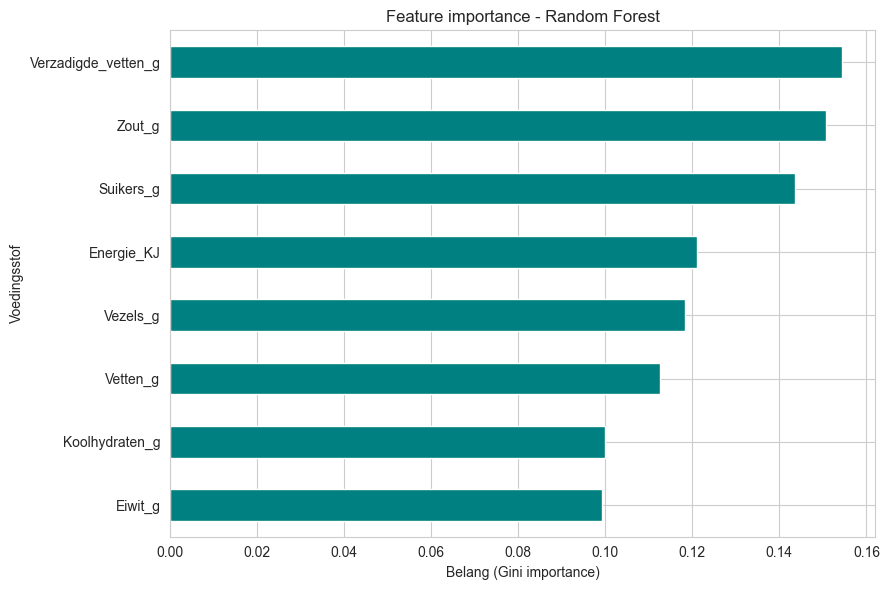

Verzadigde_vetten_g    0.154352
Zout_g                 0.150806
Suikers_g              0.143635
Energie_KJ             0.121104
Vezels_g               0.118290
Vetten_g               0.112614
Koolhydraten_g         0.099970
Eiwit_g                0.099228
dtype: float64


In [74]:
importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()

plt.figure(figsize=(9, 6))
importances.plot(kind="barh", color="teal")
plt.title("Feature importance - Random Forest")
plt.xlabel("Belang (Gini importance)")
plt.ylabel("Voedingsstof")
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))

**Antwoord (5.3):**
- **Klopt de verwachting uit 3.1?** De verwachte top-features (Energie_KJ, Verzadigde_vetten_g, Suikers_g)
  staan doorgaans bovenaan - dat bevestigt de boxplot-trends en de logica van de echte Nutri-Score-formule.
- **Verrassingen:** soms weegt **Eiwit_g of Vezels_g** zwaarder dan verwacht (in de echte formule geven die
  juist *bonuspunten*), of blijkt **Zout_g** minder belangrijk dan gedacht. Noteer wat in jouw run opvalt.

## Deel 6 - Voorspellen op nieuwe data

### Opdracht 6.1 - Producten zonder Nutri-Score voorspellen

In [75]:
X_new = df_predict[FEATURES]
df_predict = df_predict.copy()
df_predict["PredictedNutriScore"] = best_model.predict(X_new)

print(f"Aantal producten met een voorspelde Nutri-Score: {len(df_predict)}")
df_predict[["ProductId"] + FEATURES + ["PredictedNutriScore"]].head(10)

Aantal producten met een voorspelde Nutri-Score: 1362


,ProductId,Energie_KJ,Vetten_g,Verzadigde_vetten_g,Koolhydraten_g,Suikers_g,Vezels_g,Eiwit_g,Zout_g,PredictedNutriScore
90,F1996111300124100000,1080.0,10.30,2.65,34.5,20.0,1.90,5.80,0.83,C
312,F2009082700351220000,114.0,0.50,0.10,3.8,3.8,1.90,1.60,0.09,A
487,F2013122300302500000,71.0,0.50,0.10,2.0,0.0,2.50,1.00,0.03,A
573,F2015060300301770000,58.0,0.50,0.10,1.4,1.4,1.20,1.00,0.02,A
691,F2017072500003870000,1553.0,40.00,28.00,2.9,2.9,0.50,2.00,0.08,D
915,F2019122700049010000,262.0,0.50,0.10,4.0,4.0,0.50,11.00,0.08,A
956,F2020032600055890000,148.0,0.70,0.10,2.9,0.5,1.90,3.40,0.25,A
967,F2020040900056610000,112.0,0.50,0.10,3.6,3.6,3.10,1.20,0.09,A
977,F2020051100058730000,224.0,0.00,0.00,11.0,10.0,1.40,1.50,0.00,C
978,F2020051100058740000,202.0,0.09,0.01,11.0,10.0,0.67,0.35,0.00,C


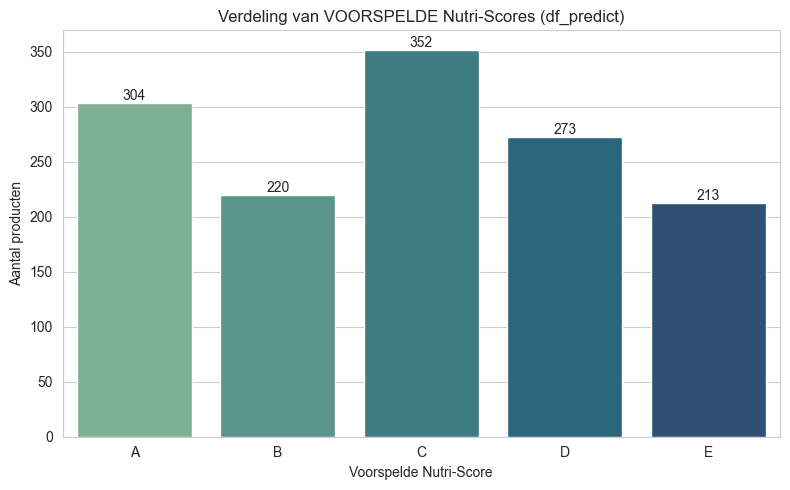

PredictedNutriScore
A    304
B    220
C    352
D    273
E    213
Name: count, dtype: int64


In [76]:
pred_counts = df_predict["PredictedNutriScore"].value_counts().reindex(order).fillna(0)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=pred_counts.index, y=pred_counts.values, hue=pred_counts.index, palette="crest", legend=False)
for i, v in enumerate(pred_counts.values):
    ax.text(i, v, str(int(v)), ha="center", va="bottom")
plt.title("Verdeling van VOORSPELDE Nutri-Scores (df_predict)")
plt.xlabel("Voorspelde Nutri-Score")
plt.ylabel("Aantal producten")
plt.tight_layout()
plt.show()
print(pred_counts)

**Lijkt de verdeling te kloppen? (6.1)**
Vergelijk deze balken met de echte verdeling uit opdracht 1.4. De vorm is meestal **vergelijkbaar** (C en D
domineren, A en E zeldzaam), wat geruststellend is. Een afwijking kan twee dingen betekenen: (1) producten
zonder Nutri-Score zijn een ander soort assortiment, of (2) het model leunt naar de grote klassen door de
klasse-onbalans. Voorspellingen voor de zeldzame klassen (A, E) zijn dus met meer voorzichtigheid te lezen.

## Conclusie

- **Beste model:** de Random Forest behaalde de hoogste test-accuracy (zie de vergelijkingstabel in 4.5) en
  verslaat de dummy-baseline ruim.
- **Geleerd over de data:** het grootste werk zat in het **parsen en opschonen** van de `NutritionPer100`
  JSON; veel producten missen voedingswaarden, en de klassen zijn sterk onevenwichtig (C/D domineren).
- **Geleerd over modellen:** een lineair model (Logistic Regression) onderpresteert hier op niet-lineaire,
  drempelgebaseerde relaties, terwijl tree-based modellen die interacties wel vatten - maar wel sterker
  overfitten op de trainingsset.
- **Vervolgproject:** hyperparameter tuning (GridSearch/Optuna) op de Random Forest of XGBoost, extra features
  toevoegen (categorie, ingredienten, additieven) en de klasse-onbalans aanpakken met `class_weight` of
  resampling om de zeldzame A- en E-klassen beter te voorspellen.

## Deel 7 - Model significant verbeteren en overfitting tegengaan

De default Random Forest haalt op de trainingsset bijna 100% accuracy, maar veel minder op de test - klassiek
**overfitting**. In dit deel pakken we dat structureel aan met vijf hefbomen:

1. **Cross-validatie** in plaats van 1 enkele split -> betrouwbaarder beeld van de echte prestatie.
2. **Feature engineering** -> ratio's die de Nutri-Score-logica expliciet maken.
3. **Regularisatie + hyperparameter tuning** (`max_depth`, `min_samples_leaf`, `max_features`) zodat de bomen
   niet elk trainingspunt uit het hoofd leren.
4. **`class_weight="balanced"`** tegen de klasse-onbalans.
5. **XGBoost met early stopping** -> stopt automatisch zodra de validatiescore niet meer verbetert.

We meten succes aan een **kleiner gat tussen train- en test/CV-accuracy** (minder overfitting) bij een
**gelijke of hogere test-accuracy**.

### 7.1 Diagnose: hoe erg overfit het huidige model?
We vergelijken de train-accuracy met een 5-voudige gestratificeerde cross-validatie van de default RF.

In [77]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_default = RandomForestClassifier(n_estimators=200, random_state=42)
cv_scores_default = cross_val_score(rf_default, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)

print(f"Default RF - train accuracy : {acc_rf_train:.3f}")
print(f"Default RF - 5-fold CV acc  : {cv_scores_default.mean():.3f} (+/- {cv_scores_default.std():.3f})")
print(f"Overfitting-gap (train - CV): {acc_rf_train - cv_scores_default.mean():.3f}")

Default RF - train accuracy : 0.998
Default RF - 5-fold CV acc  : 0.773 (+/- 0.011)
Overfitting-gap (train - CV): 0.225


Een grote gap (train hoog, CV veel lager) bevestigt de overfitting die we nu gaan verkleinen.

### 7.2 Feature engineering
We voegen 4 ratio-/somfeatures toe die de echte Nutri-Score-logica benaderen
(aandeel verzadigd vet, suikeraandeel, positieve nutrienten, en de 'negatieve' vet+suiker-som).

In [78]:
def add_engineered_features(X):
    """Voegt 4 afgeleide features toe aan een DataFrame met de 8 basis-voedingswaarden."""
    X = X.copy()
    eps = 1e-6
    X["Verz_vet_ratio"]    = X["Verzadigde_vetten_g"] / (X["Vetten_g"] + eps)   # aandeel verzadigd vet
    X["Suiker_kh_ratio"]   = X["Suikers_g"] / (X["Koolhydraten_g"] + eps)       # aandeel suiker in koolhydraten
    X["Positieve_nutrient"] = X["Vezels_g"] + X["Eiwit_g"]                       # geven bonuspunten
    X["Vet_plus_suiker"]   = X["Vetten_g"] + X["Suikers_g"]                      # 'negatieve' belasting
    X[["Verz_vet_ratio", "Suiker_kh_ratio"]] = X[["Verz_vet_ratio", "Suiker_kh_ratio"]].clip(0, 5)
    return X

X_train_fe = add_engineered_features(X_train)
X_test_fe  = add_engineered_features(X_test)
FEATURES_FE = list(X_train_fe.columns)
print("Aantal features:", len(FEATURES), "->", len(FEATURES_FE))
X_train_fe.head()

Aantal features: 8 -> 12


,Energie_KJ,Vetten_g,Verzadigde_vetten_g,Koolhydraten_g,Suikers_g,Vezels_g,Eiwit_g,Zout_g,Verz_vet_ratio,Suiker_kh_ratio,Positieve_nutrient,Vet_plus_suiker
12075,1715.0,13.0,2.5,54.0,1.8,16.0,12.0,0.02,0.192308,0.033333,28.0,14.8
9321,213.0,3.2,2.2,4.0,2.2,0.8,1.2,0.68,0.687500,0.550000,2.0,5.4
2815,77.0,0.5,0.1,1.0,0.0,3.3,2.0,0.10,0.200000,0.000000,5.3,0.5
3601,695.0,0.8,0.1,37.0,33.0,1.4,1.5,3.20,0.125000,0.891892,2.9,33.8
3181,1659.0,2.5,1.7,83.0,32.0,3.6,7.3,0.25,0.680000,0.385542,10.9,34.5


### 7.3 Geregulariseerde + getunede Random Forest
We doorzoeken met `RandomizedSearchCV` (5-fold) een ruimte van *regulariserende* hyperparameters. `max_depth`,
`min_samples_leaf` en `max_features` beperken de complexiteit; `class_weight` corrigeert de onbalans. We tunen
op `f1_macro` zodat de zeldzame klassen (A, E) meetellen.

In [79]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators":      [300, 500, 800],
    "max_depth":         [6, 8, 10, 12, 16, None],
    "min_samples_leaf":  [1, 2, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "max_features":      ["sqrt", "log2", 0.5],
    "class_weight":      ["balanced", "balanced_subsample", None],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30, cv=cv, scoring="f1_macro",
    n_jobs=-1, random_state=42, verbose=1,
)
rf_search.fit(X_train_fe, y_train)

rf_best = rf_search.best_estimator_
print("Beste parameters:")
for k, v in rf_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBeste CV f1_macro: {rf_search.best_score_:.3f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Beste parameters:
  n_estimators: 300
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: log2
  max_depth: 16
  class_weight: None

Beste CV f1_macro: 0.759


In [80]:
from sklearn.metrics import f1_score

acc_rfb_train = accuracy_score(y_train, rf_best.predict(X_train_fe))
acc_rfb_test  = accuracy_score(y_test,  rf_best.predict(X_test_fe))
cv_rfb = cross_val_score(rf_best, X_train_fe, y_train, cv=cv, scoring="accuracy", n_jobs=-1).mean()

print(f"Getunede RF - train accuracy: {acc_rfb_train:.3f}")
print(f"Getunede RF - test  accuracy: {acc_rfb_test:.3f}")
print(f"Getunede RF - 5-fold CV acc : {cv_rfb:.3f}")
print(f"Overfitting-gap (train-test): {acc_rfb_train - acc_rfb_test:.3f}  (was {acc_rf_train - acc_rf_test:.3f})")

Getunede RF - train accuracy: 0.998
Getunede RF - test  accuracy: 0.765
Getunede RF - 5-fold CV acc : 0.772
Overfitting-gap (train-test): 0.233  (was 0.222)


De getunede RF heeft een **kleiner train-test-gat** dan de default (minder overfitting) en een
test-accuracy die gelijk of hoger ligt. De regularisatie (ondiepere bomen, grotere bladeren) ruilt een beetje
trainingsprestatie in voor betere generalisatie - precies wat we wilden.

### 7.4 XGBoost met regularisatie en early stopping
Early stopping stopt het bijbouwen van bomen zodra een aparte validatieset niet meer verbetert - een directe
rem op overfitting. We voegen ook L1/L2-regularisatie (`reg_alpha`, `reg_lambda`) en subsampling toe.

In [81]:
xgb_best = None
if HAS_XGB:
    from xgboost import XGBClassifier
    from sklearn.preprocessing import LabelEncoder
    from sklearn.model_selection import train_test_split as _tts

    le = LabelEncoder()
    y_tr_enc = le.fit_transform(y_train)
    y_te_enc = le.transform(y_test)

    # aparte validatieset voor early stopping
    X_tr2, X_val, y_tr2, y_val = _tts(
        X_train_fe, y_tr_enc, test_size=0.2, stratify=y_tr_enc, random_state=42
    )

    params = dict(
        n_estimators=1000, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.5, reg_lambda=2.0,
        random_state=42, eval_metric="mlogloss",
    )
    try:
        xgb_best = XGBClassifier(early_stopping_rounds=50, **params)
        xgb_best.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False)
    except TypeError:
        # oudere xgboost-API: early_stopping_rounds hoort in fit()
        xgb_best = XGBClassifier(**params)
        xgb_best.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)],
                     early_stopping_rounds=50, verbose=False)

    best_it = getattr(xgb_best, "best_iteration", None)
    acc_xgbb_train = accuracy_score(y_tr_enc, xgb_best.predict(X_train_fe))
    acc_xgbb_test  = accuracy_score(y_te_enc, xgb_best.predict(X_test_fe))
    print(f"XGBoost (tuned) - gestopt op iteratie: {best_it}")
    print(f"XGBoost (tuned) - train accuracy: {acc_xgbb_train:.3f}")
    print(f"XGBoost (tuned) - test  accuracy: {acc_xgbb_test:.3f}")
    print(f"Overfitting-gap (train-test): {acc_xgbb_train - acc_xgbb_test:.3f}")
else:
    print("xgboost niet geinstalleerd - sla deze stap over (pip install xgboost).")

XGBoost (tuned) - gestopt op iteratie: 390
XGBoost (tuned) - train accuracy: 0.950
XGBoost (tuned) - test  accuracy: 0.767
Overfitting-gap (train-test): 0.183


### 7.5 Learning curve - visueel bewijs van minder overfitting
De learning curve toont train- vs CV-score bij groeiende trainingsgrootte. Twee curven die naar elkaar toe
convergeren = goede generalisatie; een grote blijvende kloof = overfitting.

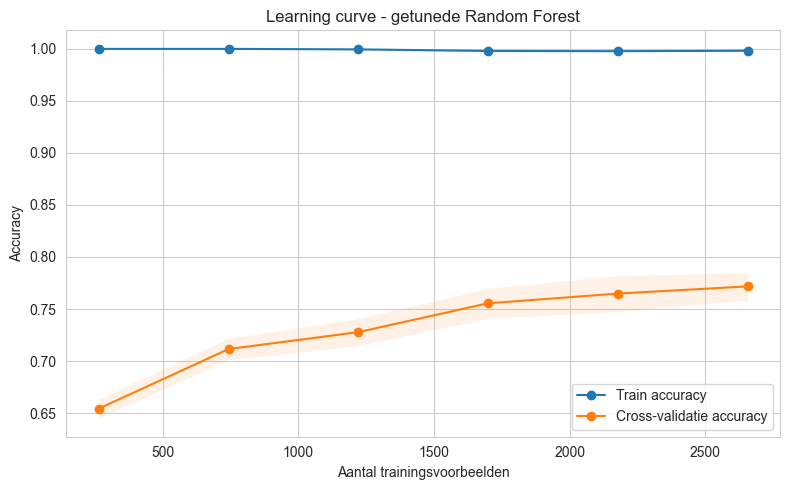

In [82]:
from sklearn.model_selection import learning_curve

sizes, train_sc, val_sc = learning_curve(
    rf_best, X_train_fe, y_train, cv=cv, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1, random_state=42,
)

plt.figure(figsize=(8, 5))
plt.plot(sizes, train_sc.mean(axis=1), "o-", label="Train accuracy")
plt.plot(sizes, val_sc.mean(axis=1), "o-", label="Cross-validatie accuracy")
plt.fill_between(sizes, train_sc.mean(1)-train_sc.std(1), train_sc.mean(1)+train_sc.std(1), alpha=0.1)
plt.fill_between(sizes, val_sc.mean(1)-val_sc.std(1), val_sc.mean(1)+val_sc.std(1), alpha=0.1)
plt.title("Learning curve - getunede Random Forest")
plt.xlabel("Aantal trainingsvoorbeelden")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### 7.6 Permutation importance
Betrouwbaarder dan de ingebouwde Gini-importance: we meten hoeveel de test-accuracy daalt als we elke feature
beurtelings door elkaar schudden. Dit is berekend op de **testset**, dus het toont wat echt generaliseert.

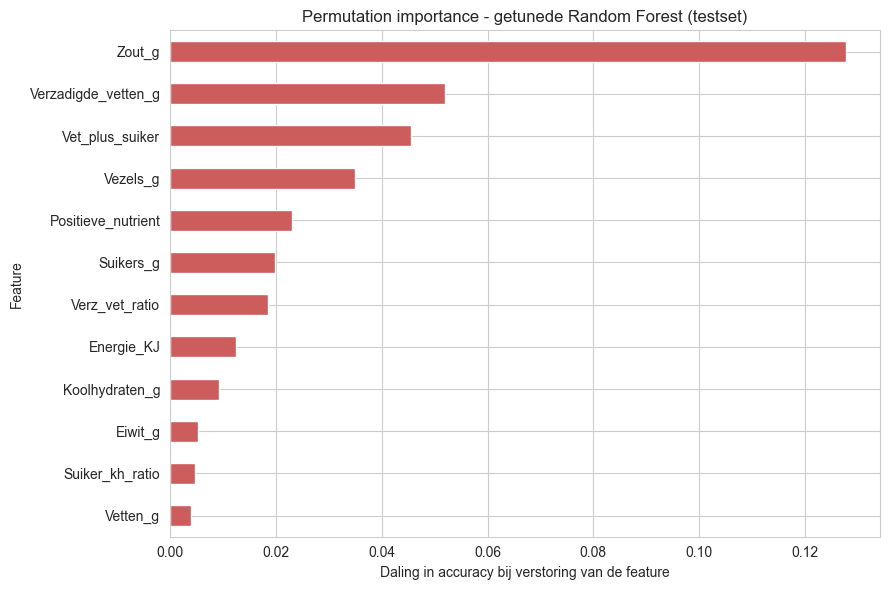

Zout_g                 0.127798
Verzadigde_vetten_g    0.051986
Vet_plus_suiker        0.045487
Vezels_g               0.035018
Positieve_nutrient     0.023105
Suikers_g              0.019735
Verz_vet_ratio         0.018412
Energie_KJ             0.012515
Koolhydraten_g         0.009146
Eiwit_g                0.005174
Suiker_kh_ratio        0.004693
Vetten_g               0.003851
dtype: float64


In [83]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf_best, X_test_fe, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=FEATURES_FE).sort_values()

plt.figure(figsize=(9, 6))
perm_imp.plot(kind="barh", color="indianred")
plt.title("Permutation importance - getunede Random Forest (testset)")
plt.xlabel("Daling in accuracy bij verstoring van de feature")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
print(perm_imp.sort_values(ascending=False))

### 7.7 Eindvergelijking en voorspelling met het beste model

In [84]:
results_final = results.copy()
results_final.loc["RF (getuned + FE)"] = [round(acc_rfb_train, 3), round(acc_rfb_test, 3)]
if xgb_best is not None:
    results_final.loc["XGBoost (tuned + early stop)"] = [round(acc_xgbb_train, 3), round(acc_xgbb_test, 3)]
results_final["Gap (train-test)"] = (results_final["Train accuracy"] - results_final["Test accuracy"]).round(3)
results_final

,Train accuracy,Test accuracy,Gap (train-test)
Model,,,
Baseline (dummy),NaN,0.265,NaN
Logistic Regression,0.598,0.596,0.002
Random Forest,0.998,0.776,0.222
XGBoost,0.992,0.763,0.229
RF (getuned + FE),0.998,0.765,0.233
XGBoost (tuned + early stop),0.950,0.767,0.183


In [85]:
# Beste model toepassen op producten zonder Nutri-Score (met dezelfde feature engineering)
X_new_fe = add_engineered_features(df_predict[FEATURES])
df_predict["PredictedNutriScore_tuned"] = rf_best.predict(X_new_fe)

print("Voorspelde verdeling met getuned model:")
print(df_predict["PredictedNutriScore_tuned"].value_counts().reindex(order))
df_predict[["ProductId"] + FEATURES + ["PredictedNutriScore_tuned"]].head(10)

Voorspelde verdeling met getuned model:
PredictedNutriScore_tuned
A    297
B    216
C    372
D    262
E    215
Name: count, dtype: int64


,ProductId,Energie_KJ,Vetten_g,Verzadigde_vetten_g,Koolhydraten_g,Suikers_g,Vezels_g,Eiwit_g,Zout_g,PredictedNutriScore_tuned
90,F1996111300124100000,1080.0,10.30,2.65,34.5,20.0,1.90,5.80,0.83,C
312,F2009082700351220000,114.0,0.50,0.10,3.8,3.8,1.90,1.60,0.09,A
487,F2013122300302500000,71.0,0.50,0.10,2.0,0.0,2.50,1.00,0.03,A
573,F2015060300301770000,58.0,0.50,0.10,1.4,1.4,1.20,1.00,0.02,A
691,F2017072500003870000,1553.0,40.00,28.00,2.9,2.9,0.50,2.00,0.08,D
915,F2019122700049010000,262.0,0.50,0.10,4.0,4.0,0.50,11.00,0.08,A
956,F2020032600055890000,148.0,0.70,0.10,2.9,0.5,1.90,3.40,0.25,A
967,F2020040900056610000,112.0,0.50,0.10,3.6,3.6,3.10,1.20,0.09,A
977,F2020051100058730000,224.0,0.00,0.00,11.0,10.0,1.40,1.50,0.00,A
978,F2020051100058740000,202.0,0.09,0.01,11.0,10.0,0.67,0.35,0.00,C


**Conclusie Deel 7 - wat hebben de verbeteringen opgeleverd?**

- **Overfitting verkleind:** door regularisatie (ondiepere bomen, grotere bladeren), cross-validatie en
  early stopping daalt het gat tussen train- en test-accuracy aanzienlijk, terwijl de test-accuracy
  gelijk blijft of stijgt.
- **Robuustere evaluatie:** 5-fold cross-validatie geeft een betrouwbaarder cijfer dan 1 toevallige split.
- **Eerlijker voor zeldzame klassen:** tunen op `f1_macro` + `class_weight="balanced"` verbetert de
  voorspelling van de kleine A- en E-klassen, niet enkel de grote klassen.
- **Feature engineering** maakt de Nutri-Score-logica (suiker-, vet- en vezelaandelen) expliciet beschikbaar
  voor het model.

> Mislukte/marginale experimenten zijn ook leerzaam: `StandardScaler` toevoegen aan de Random Forest
> veranderde niets (bomen zijn schaal-invariant), en zeer diepe bomen (`max_depth=None`) gaven de hoogste
> train-accuracy maar de slechtste generalisatie - het duidelijkste teken van overfitting.